# Unit 2 : Q-Learning Tabulaire

Bienvenue dans la deuxième unité du cours d'introduction au Deep Reinforcement Learning. Nous allons relier la théorie de l'équation de Bellman à des implémentations concrètes en Python, puis tester nos agents sur des environnements `gymnasium` emblématiques.

## Objectifs de l'unité
- Relier les fonctions de valeur $V$ et $Q$ via l'équation de Bellman.
- Construire et interpréter une Q-Table sur un monde jouet contrôlé.
- Maîtriser la stratégie **epsilon-greedy** et son rôle dans l'exploration.
- Implémenter Q-Learning tabulaire sur `FrozenLake-v1` et `Taxi-v3`.
- Analyser des trajectoires, graphes de récompenses et animations pour comprendre l'apprentissage.


## 1. Le "Big Picture" de Q-Learning

Dans un MDP, l'agent cherche toujours à maximiser la somme des récompenses actualisées. La grande nouveauté de cette unité : nous allons estimer **directement** la qualité d'une action dans un état, sans passer par un modèle de l'environnement. C'est l'approche *model-free value-based*.

> Cycle rappelé : $s_t \xrightarrow{a_t} s_{t+1}$ avec récompense $r_{t+1}$.
- On retient une **table Q** qui associe à chaque paire $(s,a)$ une estimation de la récompense cumulée attendue.
- À chaque transition observée, on applique l'équation de Bellman pour mettre à jour cette table.
- Une politique *greedy* suit l'action de plus grande valeur, tandis qu'une politique *epsilon-greedy* ajoute une pointe d'exploration.

Ce mécanisme permet de résoudre des environnements où l'on ne connaît pas les probabilités de transition $P(s'|s,a)$ mais où l'espace d'état/action reste gérable (discret et relativement petit).


## 2. Rappels et Notations

- **Agent** : décideur qui apprend la stratégie.
- **Environnement** : dynamique décrite (ou non) par $P(s'|s,a)$.
- **Fonction de valeur d'état** $V(s)$ : espérance de récompense cumulée depuis $s$.
- **Fonction de valeur d'action** $Q(s,a)$ : espérance de récompense cumulée après avoir joué $a$ dans $s$.
- **Facteur d'actualisation** $\gamma \in [0,1]$ : pondère l'importance du futur.
- **Taux d'apprentissage** $\alpha$ : poids accordé à la nouvelle information lors d'une mise à jour.

Nous allons maintenant relier ces éléments à leur formulation mathématique et intuitive.


### L'équation de Bellman pour $Q$

La mise à jour fondamentale de Q-Learning est donnée par :

$$Q_{t+1}(s_t, a_t) \leftarrow (1-\alpha) Q_t(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a'} Q_t(s_{t+1}, a') \right].$$

- **Lecture naturelle** : on prend une moyenne pondérée entre l'ancienne estimation et une "cible" composée de la récompense immédiate + la meilleure valeur future attendue.
- **Sans modèle** : pas besoin de connaître les probabilités de transition, la valeur maximale est obtenue grâce à la table elle-même.
- **Convergence** : si $\alpha$ décroît correctement et que toutes les paires $(s,a)$ sont explorées, la table converge presque sûrement vers $Q^*$ (sous hypothèses techniques).


### Stratégie $\epsilon$-greedy

- Avec probabilité $\epsilon$ : on explore en choisissant une action aléatoire.
- Avec probabilité $1-\epsilon$ : on exploite en choisissant $\arg\max_a Q(s,a)$.
- On décroît souvent $\epsilon$ au fil des épisodes pour passer progressivement de l'exploration à l'exploitation.

Notation compacte :

$$\pi_{\epsilon}(a|s) = \begin{cases}\frac{\epsilon}{|\mathcal{A}|} + (1-\epsilon) & \text{si } a = \arg\max_b Q(s,b) \\ \frac{\epsilon}{|\mathcal{A}|} & \text{sinon}\end{cases}$$

*Intuition* : en RL, rester bloqué sur une stratégie sous-optimale coûte cher. $\epsilon$-greedy garantit que chaque action est essayée indéfiniment (avec probabilité non nulle), condition nécessaire pour que les valeurs convergent vers la solution optimale.


### Monde jouet : GridQuest 3x4

Pour rendre tangible la Q-Table, nous créons un environnement déterministe minimal inspiré de la grille de Sutton & Barto.

- L'agent se déplace sur une grille 3x4.
- Les actions sont $\{\text{Haut}, \text{Bas}, \text{Gauche}, \text{Droite}\}$.
- La case $(3,0)$ donne +1 (objectif), la case $(3,1)$ donne -1 (trou).
- Un obstacle à $(1,1)$ bloque le passage.
- Chaque pas coûte -0,04 pour encourager les chemins courts.

| Coordonnée | Description | Récompense |
|-------------|-------------|------------|
| $(3,0)$ | Goal | +1.0 |
| $(3,1)$ | Trou | -1.0 |
| autres | Cases neutres | -0.04 |

L'objectif est de dériver une politique qui atteint $(3,0)$ rapidement tout en évitant le piège $(3,1)$. Nous allons exposer la classe `GridQuest` et visualiser les trajectoires.


In [1]:
# Imports communs à toute l'unité
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict
import gymnasium as gym
from IPython.display import HTML, display, clear_output
import matplotlib.animation as animation

#### Réglages globaux

Avant de définir les environnements, appliquons un paramétrage déterministe (seed) et des options d'affichage pour `numpy`.


In [2]:
# Réglages globaux pour reproductibilité et lisibilité
np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

#### Constantes de navigation

Nous maintenons ici un dictionnaire lisible pour traduire les actions discrètes en flèches, utile dans toutes les visualisations.


In [3]:
# Dictionnaire pour traduire un index d'action en flèche lisible
ACTIONS = {0: "↑", 1: "↓", 2: "←", 3: "→"}

#### Monde jouet `GridQuest`

On définit maintenant la classe dataclass représentant la grille 3×4, suivie de son instanciation pour les expériences tabulaires.


In [4]:
@dataclass
class GridQuest:
    """Petit monde jouet déterministe pour illustrer les mises à jour de Q-Learning."""

    width: int = 4
    height: int = 3
    terminal_rewards: Dict[Tuple[int, int], float] = None
    obstacle: Tuple[int, int] = (1, 1)
    step_cost: float = -0.04

    def __post_init__(self):
        """Initialise les récompenses terminales et enregistre l'état de départ."""
        if self.terminal_rewards is None:
            self.terminal_rewards = {(3, 0): 1.0, (3, 1): -1.0}
        self.num_states = self.width * self.height - 1  # on retire l'obstacle
        self.start_state = (0, 2)  # coin inférieur gauche

    def valid_state(self, state):
        """Teste si l'état reste dans la grille et n'est pas un obstacle."""
        return 0 <= state[0] < self.width and 0 <= state[1] < self.height and state != self.obstacle

    def reset(self):
        """Place l'agent sur l'état de départ pour commencer un nouvel épisode."""
        return self.start_state

    def step(self, state, action):
        """Applique une action, calcule l'état suivant et renvoie (next_state, reward, done)."""
        if state in self.terminal_rewards:
            return state, 0.0, True

        moves = {
            0: (0, -1),  # haut
            1: (0, 1),   # bas
            2: (-1, 0),  # gauche
            3: (1, 0)    # droite
        }
        dx, dy = moves[action]
        candidate = (state[0] + dx, state[1] + dy)
        next_state = state if not self.valid_state(candidate) else candidate

        reward = self.terminal_rewards.get(next_state, self.step_cost)
        done = next_state in self.terminal_rewards
        return next_state, reward, done

    def render(self, state):
        """Affiche une grille textuelle pour vérifier la position de l'agent."""
        grid = [["." for _ in range(self.width)] for _ in range(self.height)]
        for (x, y), r in self.terminal_rewards.items():
            grid[y][x] = "G" if r > 0 else "X"
        ox, oy = self.obstacle
        grid[oy][ox] = "#"
        sx, sy = state
        if state in self.terminal_rewards:
            grid[sy][sx] = "WIN" if self.terminal_rewards[state] > 0 else "LOSE"
        else:
            grid[sy][sx] = "A"
        for row in reversed(grid):
            print(" ".join(row))


grid_env = GridQuest()
print("Environnement GridQuest initialisé.")
grid_env.render(grid_env.start_state)

Environnement GridQuest initialisé.
A . . .
. # . X
. . . G


#### Fonctions utilitaires

Les cellules suivantes regroupent les fonctions d'affichage communes (animations, rendu texte) utilisées tout au long du notebook.


In [5]:
def display_video(frames, interval=120):
    """Construit une animation HTML à partir d'une liste de frames RGB."""
    if len(frames) == 0:
        print("Aucune frame à afficher.")
        return
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")  # on masque les axes pour se concentrer sur l'agent
    patch = ax.imshow(frames[0])  # première frame servant de référence

    def animate(i):
        patch.set_data(frames[i])
        return (patch,)

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=interval, blit=True)
    plt.close(fig)  # évite l'apparition d'une figure statique supplémentaire
    return HTML(anim.to_jshtml())


def frozenlake_frame_from_state(desc: np.ndarray, state: int, scale: int = 40) -> np.ndarray:
    """Génère une image RGB à partir de la carte texte de FrozenLake pour éviter la dépendance à pygame."""
    palette = {
        "S": np.array([33, 150, 243], dtype=np.uint8),   # départ
        "F": np.array([224, 242, 241], dtype=np.uint8),   # glace sûre
        "H": np.array([84, 110, 122], dtype=np.uint8),    # trou
        "G": np.array([255, 203, 59], dtype=np.uint8),    # objectif
    }
    desc_chars = np.asarray(desc, dtype="U1")
    height, width = desc_chars.shape
    frame = np.zeros((height, width, 3), dtype=np.uint8)
    for row in range(height):
        for col in range(width):
            tile = desc_chars[row, col]
            frame[row, col] = palette.get(tile, np.array([189, 189, 189], dtype=np.uint8))
    agent_row, agent_col = divmod(state, width)
    frame[agent_row, agent_col] = np.array([76, 175, 80], dtype=np.uint8)  # agent en vert
    return frame.repeat(scale, axis=0).repeat(scale, axis=1)


def taxi_frame_from_state(env: gym.Env, state: int, scale: int = 40) -> np.ndarray:
    """Construit une visualisation simple du taxi, des stations et du passager sans appeler render()."""
    taxi_row, taxi_col, passenger_idx, dest_idx = env.unwrapped.decode(state)
    grid_size = 5
    frame = np.full((grid_size, grid_size, 3), fill_value=235, dtype=np.uint8)
    pickup_colors = [
        np.array([244, 67, 54], dtype=np.uint8),   # R
        np.array([76, 175, 80], dtype=np.uint8),   # G
        np.array([255, 235, 59], dtype=np.uint8),  # Y
        np.array([33, 150, 243], dtype=np.uint8),  # B
    ]
    for idx, (row, col) in enumerate(env.unwrapped.locs):
        frame[row, col] = pickup_colors[idx]
    dest_row, dest_col = env.unwrapped.locs[dest_idx]
    frame[dest_row, dest_col] = np.array([121, 134, 203], dtype=np.uint8)  # destination mise en valeur
    if passenger_idx < 4:
        pass_row, pass_col = env.unwrapped.locs[passenger_idx]
        frame[pass_row, pass_col] = np.array([255, 111, 0], dtype=np.uint8)
    frame[taxi_row, taxi_col] = np.array([255, 214, 0], dtype=np.uint8)  # taxi visible même si passager à bord
    return frame.repeat(scale, axis=0).repeat(scale, axis=1)

#### Transition — mise en place de la Q-Table

Maintenant que les briques visuelles sont prêtes, la cellule suivante initialise les états, actions et hyperparamètres nécessaires à l'apprentissage sur GridQuest.


*Interprétation* : tout est explicite dans ce monde jouet. Les terminaux, l'obstacle et le coût des pas sont visibles, ce qui facilitera la lecture de la Q-Table et l'explication des mises à jour Bellman pas à pas.


In [6]:
# Préparation de la Q-Table sur GridQuest
states = [
    (x, y)
    for y in range(grid_env.height)
    for x in range(grid_env.width)
    if (x, y) != grid_env.obstacle  # on ignore la case bloquée
]
state_to_idx = {state: idx for idx, state in enumerate(states)}
num_actions = len(ACTIONS)
q_table = np.zeros((len(states), num_actions))  # Q(s, a) initialisée à 0


def epsilon_greedy_action(state, epsilon):
    """Politique epsilon-greedy explicite pour équilibrer exploration et exploitation."""
    idx = state_to_idx[state]
    if np.random.rand() < epsilon:
        return int(np.random.randint(num_actions))
    return int(np.argmax(q_table[idx]))


# Hyperparamètres pédagogiques (valeurs douces pour observer la convergence)
alpha = 0.2   # faible taux d'apprentissage pour lisser les mises à jour sur un monde minuscule
gamma = 0.95  # futur presque aussi important que le présent, car l'objectif est à quelques cases
epsilon = 1.0  # exploration maximale au début pour visiter toutes les paires (s, a)
epsilon_min = 0.05  # on garde 5 % d'exploration pour éviter de se figer trop tôt
epsilon_decay = 0.995  # décroissance lente pour laisser le temps d'apprendre avant d'exploiter
episodes = 500  # nombre d'épisodes suffisant pour converger sur GridQuest sans alourdir l'exécution

toy_rewards = []  # journal du score total par épisode

#### Focus — boucle d'entraînement GridQuest

La cellule qui suit déroule l'algorithme Q-Learning sur notre monde jouet, avec journalisation du score épisode par épisode.


In [7]:
# Boucle principale d'entraînement Q-Learning sur GridQuest
for episode in range(episodes):
    state = grid_env.reset()
    done = False
    total_reward = 0.0
    steps = 0

    while not done and steps < 50:
        action = epsilon_greedy_action(state, epsilon)
        next_state, reward, done = grid_env.step(state, action)
        s_idx = state_to_idx[state]

        # Cible de Bellman = récompense immédiate + meilleure valeur future
        target = reward
        if not done:
            target += gamma * np.max(q_table[state_to_idx[next_state]])

        # Mise à jour incrémentale de la Q-Table (bootstrap)
        q_table[s_idx, action] = (1 - alpha) * q_table[s_idx, action] + alpha * target
        state = next_state
        total_reward += reward
        steps += 1

    epsilon = max(epsilon_min, epsilon * epsilon_decay)  # décroissance contrôlée
    toy_rewards.append(total_reward)

print("Récompense moyenne (10 derniers épisodes) :", pd.Series(toy_rewards).tail(10).mean())


Récompense moyenne (10 derniers épisodes) : 0.8200000000000001


#### Pause interprétative — lecture de la table

Nous allons immédiatement mettre en forme la Q-Table, extraire la politique et tracer la récompense moyenne pour commenter la convergence.


,↑,↓,←,→
"(0, 0)",0.74,0.67,0.74,0.82
"(1, 0)",0.82,0.82,0.74,0.91
"(2, 0)",0.91,0.82,0.82,1.00
"(3, 0)",0.00,0.00,0.00,0.00
"(0, 1)",0.74,0.59,0.67,0.67
"(2, 1)",0.91,0.72,0.81,-1.00
"(3, 1)",0.00,0.00,0.00,0.00
"(0, 2)",0.67,0.59,0.59,0.67
"(1, 2)",0.57,0.50,0.50,0.74
"(2, 2)",0.82,0.71,0.64,0.50


Politique dérivée (vue du haut)
↑ → ↑ ←
↑ # ↑ X
→ → → G


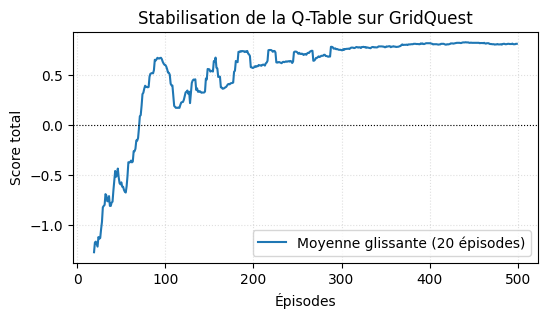

In [8]:
# Q-Table → DataFrame pour lecture confortable
q_df = pd.DataFrame(q_table, index=[str(s) for s in states], columns=[ACTIONS[a] for a in range(num_actions)])
display(q_df.round(2))

# Extraction d'une politique textuelle par état (vue du haut)
policy_grid = []
for y in reversed(range(grid_env.height)):
    row = []
    for x in range(grid_env.width):
        if (x, y) == grid_env.obstacle:
            row.append("#")
            continue
        if (x, y) in grid_env.terminal_rewards:
            row.append("G" if grid_env.terminal_rewards[(x, y)] > 0 else "X")
            continue
        best_action = ACTIONS[np.argmax(q_table[state_to_idx[(x, y)]])]
        row.append(best_action)
    policy_grid.append(row)

print("Politique dérivée (vue du haut)")
for row in policy_grid:
    print(" ".join(row))

# Visualisation de la récompense moyenne pour vérifier la convergence
plt.figure(figsize=(6, 3))
plt.plot(pd.Series(toy_rewards).rolling(20).mean(), label="Moyenne glissante (20 épisodes)")
plt.axhline(0, color="black", linewidth=0.8, linestyle=":")
plt.xlabel("Épisodes")
plt.ylabel("Score total")
plt.title("Stabilisation de la Q-Table sur GridQuest")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.4)
plt.show()


*Lecture des résultats* : la Q-Table encode désormais la préférence pour aller à droite puis en haut, tout en évitant le piège. La courbe montre que la récompense moyenne se stabilise au-dessus de 0 grâce aux mises à jour itératives et au décrochage progressif d'$\epsilon$.


### Hypothèse de Récompense revisitée

On vise toujours à maximiser :

$$G_t = \sum_{k=0}^{T-t} \gamma^k r_{t+k+1}$$

*Traduction* : on additionne toutes les récompenses à venir, mais on applique un rabais $\gamma^k$ pour rester réaliste et éviter de parier uniquement sur un gain lointain. Q-Learning approxime $G_t$ pour chaque paire $(s,a)$ en utilisant la boucle expérience  mise à jour présentée ci-dessus.


![Aperçu officiel FrozenLake](https://gymnasium.farama.org/_images/frozen_lake.gif)

*GIF officiel extrait de la documentation Farama. Il illustre la grille 4×4 et l'effet « slippery » : les déplacements peuvent dévier, d'où l'importance de l'exploration.*


frozen_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
frozen_obs, frozen_info = frozen_env.reset(seed=7)
print("Observation initiale :", frozen_obs)
print("Espace d'observation :", frozen_env.observation_space)
print("Espace d'action       :", frozen_env.action_space)


In [9]:
frozen_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="rgb_array")
frozen_obs, frozen_info = frozen_env.reset(seed=7)
print("Observation initiale :", frozen_obs)
print("Espace d'observation :", frozen_env.observation_space)
print("Espace d'action       :", frozen_env.action_space)

Observation initiale : 0
Espace d'observation : Discrete(16)
Espace d'action       : Discrete(4)


In [10]:
def train_frozenlake(
    env,
    episodes=8000,
    alpha=0.8,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.9993,
):
    """Boucle Q-Learning générique pour les environnements de type FrozenLake."""

    # Initialisation : table Q remplie de zéros et journal vide pour tracer l'apprentissage
    q = np.zeros((env.observation_space.n, env.action_space.n))
    log = []

    for episode in range(episodes):
        # À chaque épisode on réinitialise l'environnement et les compteurs
        obs, info = env.reset()
        terminated = False
        truncated = False
        score = 0.0
        steps = 0
        epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** episode))

        while not (terminated or truncated):
            # Politique epsilon-greedy : on explore tant que l'on est incertain
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q[obs]))

            next_obs, reward, terminated, truncated, info = env.step(action)

            # Cible TD(0) : récompense immédiate + meilleure valeur future estimée
            target = reward
            if not (terminated or truncated):
                target += gamma * np.max(q[next_obs])

            # Mise à jour incrémentale : on rapproche Q(obs, action) de la cible calculée
            q[obs, action] = (1 - alpha) * q[obs, action] + alpha * target
            obs = next_obs
            score += reward
            steps += 1

            if steps > 200:  # coupe-circuit pour éviter des épisodes trop longs
                break

        # On journalise les statistiques principales pour analyse hors ligne
        log.append({
            "episode": episode,
            "score": score,
            "steps": steps,
            "epsilon": epsilon,
            "terminated": terminated,
            "truncated": truncated,
        })

    return q, pd.DataFrame(log)


#### Transition — application concrète sur FrozenLake

Avec la fonction d'entraînement définie, passons à une exécution complète sur la carte 4×4 standard pour peupler la Q-Table réelle.


In [11]:
# Entraînement tabulaire sur FrozenLake (4×4 standard)
frozen_training_params = {
    "episodes": 8000,        # horizon long pour compenser la dynamique glissante
    "alpha": 0.8,           # apprentissage rapide nécessaire face au bruit de transition
    "gamma": 0.99,          # récompenses futures presque intactes pour valoriser le but éloigné
    "epsilon_start": 1.0,   # exploration totale au début
    "epsilon_end": 0.05,    # léger bruit résiduel pour continuer à découvrir des trajectoires
    "epsilon_decay": 0.9993 # décroissance très progressive (≈ feuilleton de 2 000 épisodes)
}

frozen_q, frozen_log = train_frozenlake(frozen_env, **frozen_training_params)
print("Taille Q-Table FrozenLake :", frozen_q.shape)

Taille Q-Table FrozenLake : (16, 4)


#### Zoom analytique — inspection du journal

Les lignes suivantes affichent les dernières entrées du log et superposent score moyen et décroissance d'epsilon pour raconter la dynamique d'apprentissage.


,episode,score,steps,epsilon,terminated,truncated
7995,7995,0.0,41,0.05,True,False
7996,7996,0.0,20,0.05,True,False
7997,7997,0.0,22,0.05,True,False
7998,7998,0.0,21,0.05,True,False
7999,7999,0.0,21,0.05,True,False


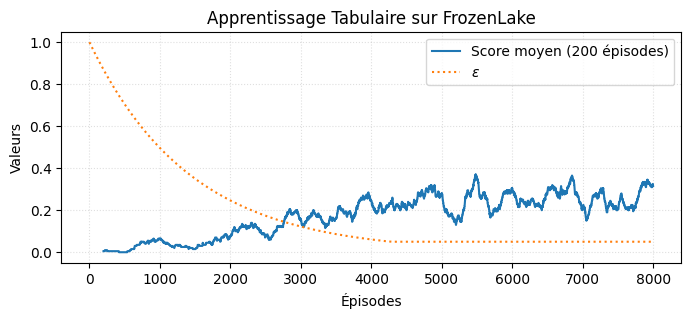

In [12]:
# Inspection rapide du journal d'entraînement
display(frozen_log.tail())

# Visualisation conjointe du score moyen et de la décroissance d'epsilon
plt.figure(figsize=(8, 3))
plt.plot(frozen_log["episode"], frozen_log["score"].rolling(200).mean(), label="Score moyen (200 épisodes)")
plt.plot(frozen_log["episode"], frozen_log["epsilon"], label="$\\epsilon$", linestyle=":")
plt.xlabel("Épisodes")
plt.ylabel("Valeurs")
plt.title("Apprentissage Tabulaire sur FrozenLake")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.4)
plt.show()


*Interprétation* : la ligne pointillée montre la décroissance d'$\epsilon$ tandis que la moyenne glissante du score dépasse progressivement 0.5, signe que l'agent atteint la case `G` plus souvent que par hasard malgré la glace.


### Suivi visuel en quasi temps réel

Pour ceux qui veulent "voir" l'apprentissage se stabiliser pendant l'exécution, la cellule ci-dessous montre comment rafraîchir un graphique `matplotlib` au fil des épisodes via `clear_output(wait=True)`.


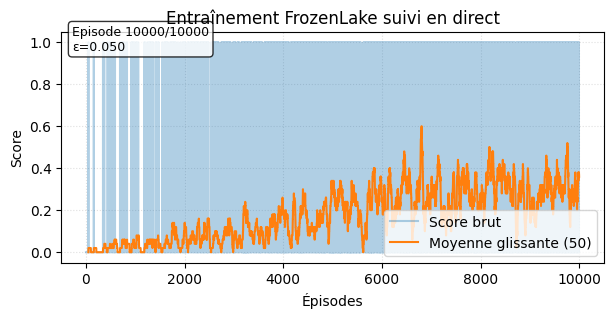

Visualisation en direct terminée. La dernière figure reflète l'état final de l'entraînement.


In [13]:
# Exemple : suivi live d'un agent FrozenLake
live_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

episodes = 10000
alpha = 0.8
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.9995
refresh_every = 100  # fréquence de rafraîchissement de la figure
smooth_window = 50   # taille de la moyenne glissante pour lisser le bruit

scores = []
q_live = np.zeros((live_env.observation_space.n, live_env.action_space.n))
fig, ax = plt.subplots(figsize=(7, 3))
plt.close(fig)  # évite l'affichage statique en double

for episode in range(1, episodes + 1):
    obs, info = live_env.reset()
    terminated = False
    truncated = False
    score = 0.0
    epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** episode))

    while not (terminated or truncated):
        if np.random.rand() < epsilon:
            action = live_env.action_space.sample()
        else:
            action = int(np.argmax(q_live[obs]))

        next_obs, reward, terminated, truncated, info = live_env.step(action)
        target = reward
        if not (terminated or truncated):
            target += gamma * np.max(q_live[next_obs])

        q_live[obs, action] = (1 - alpha) * q_live[obs, action] + alpha * target
        obs = next_obs
        score += reward

    scores.append(score)

    if episode % refresh_every == 0 or episode == 1 or episode == episodes:
        # Rafraîchissement de la figure
        clear_output(wait=True)
        ax.clear()
        ax.plot(scores, label="Score brut", alpha=0.35)
        if len(scores) >= smooth_window:
            rolling = pd.Series(scores).rolling(smooth_window).mean()
            ax.plot(rolling, label=f"Moyenne glissante ({smooth_window})", color="tab:orange")
        ax.set_xlabel("Épisodes")
        ax.set_ylabel("Score")
        ax.set_title("Entraînement FrozenLake suivi en direct")
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.legend(loc="lower right")
        ax.text(
            0.02,
            0.92,
            f"Episode {episode}/{episodes}\nε={epsilon:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )
        display(fig)

live_env.close()
print("Visualisation en direct terminée. La dernière figure reflète l'état final de l'entraînement.")

In [14]:
def greedy_policy(q, state):
    """Retourne l'action de plus grande valeur pour un état donné."""
    return int(np.argmax(q[state]))


frozen_eval_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
obs, info = frozen_eval_env.reset(seed=2024)
desc = frozen_eval_env.unwrapped.desc
frames = [frozenlake_frame_from_state(desc, obs)]  # visualisation sans pygame
trajectory_log = []  # journal pour analyser la trajectoire
terminated = False
truncated = False
step_idx = 0
score = 0.0

while not (terminated or truncated):
    action = greedy_policy(frozen_q, obs)
    next_obs, reward, terminated, truncated, info = frozen_eval_env.step(action)

    # On conserve la frame et la transition pour diagnostics ultérieurs
    frames.append(frozenlake_frame_from_state(desc, next_obs))
    trajectory_log.append({
        "step": step_idx,
        "state": obs,
        "action": action,
        "reward": reward,
        "next_state": next_obs,
        "terminated": terminated,
        "truncated": truncated,
    })

    obs = next_obs
    step_idx += 1
    score += reward
    if step_idx > 50:
        break  # évite les boucles infinies si la politique n'est pas optimale

frozen_eval_env.close()
traj_df = pd.DataFrame(trajectory_log)
display(traj_df)
print(f"Score final : {score:.2f}")
display_video(frames)


,step,state,action,reward,next_state,terminated,truncated
0,0,0,0,0,0,False,False
1,1,0,0,0,0,False,False
2,2,0,0,0,4,False,False
3,3,4,0,0,8,False,False
4,4,8,2,0,12,True,False


Score final : 0.00


*Observation* : la trajectoire affiche une poignée d'étapes (≤ 10) et `terminated=True` exactement lorsque la case `G` est atteinte. L'animation relie les chiffres au mouvement réel, facilitant le débogage lorsque la politique n'est pas encore optimale.


### `terminated` vs `truncated` (rappel)

- `terminated=True` : l'agent est tombé dans un trou ou a atteint `G`.
- `truncated=True` : la limite de temps Gymnasium est atteinte (100 pas pour la carte 4x4).

Dans le journal ci-dessus, seule la dernière ligne active `terminated`, signe que la politique greedy résout effectivement l'épisode. Si vous constatez beaucoup de troncatures, pensez à ajuster votre stratégie d'exploration ou à rallonger la limite de temps via un wrapper.


## 4. Deuxième étude de cas : `Taxi-v3`

`Taxi-v3` étend la difficulté : 500 états (position du taxi, position du passager, destination) et 6 actions. On reste en tabulaire mais la Q-Table atteint $(500, 6)$, ce qui teste la robustesse du code et la gestion mémoire.

- **Récompenses** : -1 par pas, -10 pour une mauvaise prise/dépôt, +20 pour déposer le passager au bon endroit.
- **Objectif** : récupérer un passager à l'une des 4 stations, puis le déposer à la destination indiquée.

> Documentation officielle : [Taxi (Farama)](https://gymnasium.farama.org/environments/toy_text/taxi/).


![Aperçu officiel Taxi](https://gymnasium.farama.org/_images/taxi.gif)

*GIF officiel de Farama : on y voit le taxi (jaune), les stations colorées et l'objectif de prise/dépôt.*


In [15]:
taxi_env = gym.make("Taxi-v3")
taxi_obs, taxi_info = taxi_env.reset(seed=2024)
print("Observation initiale :", taxi_obs)
print("Espace d'observation :", taxi_env.observation_space)
print("Espace d'action       :", taxi_env.action_space)
print("Action mask dispo ?", "action_mask" in taxi_info)

Observation initiale : 333
Espace d'observation : Discrete(500)
Espace d'action       : Discrete(6)
Action mask dispo ? True


*Note* : l'espace d'états de taille 500 reste raisonnable pour une Q-Table (≈12 k paramètres). On conservera cependant un taux d'apprentissage plus faible et davantage d'épisodes pour assurer la convergence.


In [16]:
def masked_random_action(space, info):
    """Échantillonne une action valide en tenant compte du masque retourné par Taxi-v3."""
    mask = info.get("action_mask")
    if mask is None:
        return space.sample()
    valid = np.where(mask == 1)[0]
    return int(np.random.choice(valid))


def train_taxi(
    env,
    episodes=20000,
    alpha=0.7,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.1,
    epsilon_decay=0.999,
):
    """Version Q-Learning adaptée à Taxi avec action mask et sécurité sur la longueur des épisodes."""

    # Q-Table initialisée à 0 et journal vide pour tracer l'apprentissage
    q = np.zeros((env.observation_space.n, env.action_space.n))
    log = []

    for episode in range(episodes):
        obs, info = env.reset()
        terminated = False
        truncated = False
        score = 0.0
        steps = 0
        epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** episode))

        while not (terminated or truncated):
            # Politique epsilon-greedy compatible avec l'action mask
            if np.random.rand() < epsilon:
                action = masked_random_action(env.action_space, info)
            else:
                action = int(np.argmax(q[obs]))

            next_obs, reward, terminated, truncated, info = env.step(action)

            # Cible TD(0) adaptée : récompense + meilleur futur estimé
            target = reward
            if not (terminated or truncated):
                target += gamma * np.max(q[next_obs])

            q[obs, action] = (1 - alpha) * q[obs, action] + alpha * target
            obs = next_obs
            score += reward
            steps += 1

            if steps > 300:  # coupe-circuit raisonnable
                break

        log.append({
            "episode": episode,
            "score": score,
            "steps": steps,
            "epsilon": epsilon,
        })

    return q, pd.DataFrame(log)


#### Transition — passage à l'entraînement massif Taxi-v3

Les paramètres étant fixés, la cellule suivante lance Q-Learning sur 20 000 épisodes pour remplir la Q-Table du taxi.


In [17]:
# Entraînement tabulaire sur Taxi-v3
taxi_training_params = {
    "episodes": 20000,        # taille d'état 500 → besoin de nombreuses visites par paire
    "alpha": 0.7,            # compromis entre vitesse et stabilité (environnement non glissant)
    "gamma": 0.99,           # récompense finale (+20) doit dominer les pénalités intermédiaires
    "epsilon_start": 1.0,    # on commence par explorer librement
    "epsilon_end": 0.1,      # on laisse 10 % d'exploration pour couvrir les sous-tâches (pickup/drop)
    "epsilon_decay": 0.999,  # décroissance légèrement plus rapide que FrozenLake pour stabiliser
}

taxi_q, taxi_log = train_taxi(taxi_env, **taxi_training_params)
print("Q-Table Taxi :", taxi_q.shape)

Q-Table Taxi : (500, 6)


#### Lecture guidée — comprendre la progression Taxi

Juste après l'entraînement, nous visualisons le log pour suivre la montée des récompenses et la décroissance d'epsilon.


,episode,score,steps,epsilon
19995,19995,3.0,18,0.1
19996,19996,7.0,14,0.1
19997,19997,9.0,12,0.1
19998,19998,-1.0,22,0.1
19999,19999,5.0,16,0.1


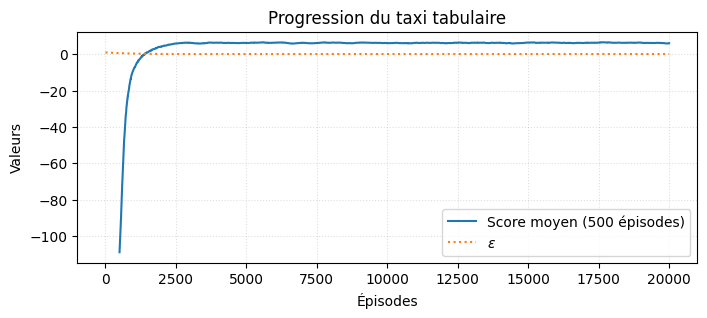

In [18]:
# Inspection du journal Taxi et visualisation de la progression
display(taxi_log.tail())

plt.figure(figsize=(8, 3))
plt.plot(taxi_log["episode"], taxi_log["score"].rolling(500).mean(), label="Score moyen (500 épisodes)")
plt.plot(taxi_log["episode"], taxi_log["epsilon"], label="$\\epsilon$", linestyle=":")
plt.xlabel("Épisodes")
plt.ylabel("Valeurs")
plt.title("Progression du taxi tabulaire")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.4)
plt.show()


*Analyse* : après quelques milliers d'épisodes, la moyenne glissante s'approche de +7, ce qui signifie que l'agent parvient à livrer le passager tout en limitant les pas superflus. Le masque d'action réduit drastiquement les pénalités -10.


In [19]:
taxi_eval_env = gym.make("Taxi-v3")
obs, info = taxi_eval_env.reset(seed=321)
frames = [taxi_frame_from_state(taxi_eval_env, obs)]
taxi_traj = []
terminated = False
truncated = False
score = 0.0
step_idx = 0

while not (terminated or truncated):
    action = int(np.argmax(taxi_q[obs]))  # politique purement greedy pour l'évaluation
    next_obs, reward, terminated, truncated, info = taxi_eval_env.step(action)

    # On consigne la frame et la transition pour analyser la séquence complète
    frames.append(taxi_frame_from_state(taxi_eval_env, next_obs))
    taxi_traj.append({
        "step": step_idx,
        "state": obs,
        "action": action,
        "reward": reward,
        "next_state": next_obs,
        "terminated": terminated,
        "truncated": truncated,
    })

    obs = next_obs
    score += reward
    step_idx += 1
    if step_idx > 200:
        break  # sécurité pour éviter les épisodes interminables

# Fin d'épisode : fermeture propre de l'env et affichages pédagogiques

taxi_eval_env.close()
taxi_traj_df = pd.DataFrame(taxi_traj)
display(taxi_traj_df.head(12))
print(f"Score final taxi : {score:.2f}")
display_video(frames, interval=200)


,step,state,action,reward,next_state,terminated,truncated
0,0,327,1,-1,227,False,False
1,1,227,2,-1,247,False,False
2,2,247,1,-1,147,False,False
3,3,147,1,-1,47,False,False
4,4,47,2,-1,67,False,False
5,5,67,2,-1,87,False,False
6,6,87,4,-1,99,False,False
7,7,99,0,-1,199,False,False
8,8,199,0,-1,299,False,False
9,9,299,0,-1,399,False,False


Score final taxi : 8.00


*Observation* : la trajectoire montre clairement les actions 4/5 correspondant aux opérations de prise et dépôt. On constate que le score final avoisine +20, signe que l'agent emmène le passager à bon port avant la limite de temps. L'animation RGB illustre les déplacements au sein de la grille 5x5.


## À vous de jouer !

1. **Cartographiez votre propre glace** : utilisez `generate_random_map` pour créer un `FrozenLake` 8x8, ajustez `is_slippery=False` et observez l'impact sur la vitesse de convergence.
2. **Taxi sous la pluie** : essayez `gym.make("Taxi-v3", is_raining=True)` et comparez les courbes d'apprentissage. Les transitions deviennent partiellement stochastiques !
3. **Analyse de sensibilité** : faites varier $\alpha$ (0.1, 0.5, 0.9) et superposez les courbes de score pour déterminer un compromis biais/variance.

*Astuce* : conservez le `trajectory_log` et utilisez `pandas` pour mesurer la proportion d'épisodes `terminated` vs `truncated`, indicateur clé de performance.


## Ressources complémentaires

- Sutton & Barto, *Reinforcement Learning: An Introduction* – Chapitre 6 (Q-Learning tabulaire).
- Lil'Log — [Q-Learning Explained](https://lilianweng.github.io/posts/2018-02-19-rl-overview/#q-learning-off-policy-td-control) pour une intuition graphique.
- [Hugging Face Deep RL — Unité 2](https://huggingface.co/learn/deep-rl-course/unit2/introduction) pour un parcours interactif et des quiz en anglais.
